In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from statsmodels.tsa.stattools import adfuller #Augmented Dickey-Fuller statistic test: H0 non stationary vs H1 stationary (pvalue=0.05)


In [ ]:
files = [
    # stocks
    "coal_data/individual_universe/AMR_daily_5y.csv",
    "coal_data/individual_universe/ARLP_daily_5y.csv",
    "coal_data/individual_universe/BHP_daily_5y.csv",
    "coal_data/individual_universe/BTU_daily_5y.csv",
    "coal_data/individual_universe/HNRG_daily_5y.csv",
    "coal_data/individual_universe/NC_daily_5y.csv",
    "coal_data/individual_universe/NRP_daily_5y.csv",
    "coal_data/individual_universe/RIO_daily_5y.csv",
    "coal_data/individual_universe/TECK_daily_5y.csv",
    "coal_data/individual_universe/WHC_AU_daily_5y.csv",
    "coal_data/individual_universe/YAL_AU_daily_5y.csv",

    # ETF
    "coal_data/sector_proxies/GNR_daily_5y.csv",
    "coal_data/sector_proxies/IXC_daily_5y.csv",
    "coal_data/sector_proxies/XLE_daily_5y.csv",

    # futures
    "coal_data/the_primary_anchor/Newcastle Coal Futures Historical Data.csv"
]

valid_files = []
empty_files = []

for file in files:
    try:
        df = pd.read_csv(file)
        
        if len(df) == 0:
            empty_files.append(file)
        else:
            valid_files.append(file)
            
    except:
        empty_files.append(file)

print("Valid files:", valid_files)
print("Empty files:", empty_files)

Valid files: ['coal_data/individual_universe/AMR_daily_5y.csv', 'coal_data/individual_universe/ARLP_daily_5y.csv', 'coal_data/individual_universe/BHP_daily_5y.csv', 'coal_data/individual_universe/BTU_daily_5y.csv', 'coal_data/individual_universe/HNRG_daily_5y.csv', 'coal_data/individual_universe/NC_daily_5y.csv', 'coal_data/individual_universe/NRP_daily_5y.csv', 'coal_data/individual_universe/RIO_daily_5y.csv', 'coal_data/individual_universe/TECK_daily_5y.csv', 'coal_data/individual_universe/WHC_AU_daily_5y.csv', 'coal_data/individual_universe/YAL_AU_daily_5y.csv', 'coal_data/sector_proxies/GNR_daily_5y.csv', 'coal_data/sector_proxies/IXC_daily_5y.csv', 'coal_data/sector_proxies/XLE_daily_5y.csv']
Empty files: ['coal_data/the_primary_anchor/Newcastle Coal Futures Historical Data.csv']


We have here one empty file: the identifier of Newcastle Coal Futures (which is normal)

In [4]:
#Stocks
stocks = ["AMR", "ARLP", "BHP", "BTU", "HNRG", "NC", "NRP", "RIO", "TECK","WHC_AU","YAL_AU"]

data={}
for s in stocks:
    df=pd.read_csv(f"coal_data/individual_universe/{s}_daily_5y.csv")
    df["Date"]=pd.to_datetime(df["Date"])
    df=df.set_index("Date")
    data[s]=df["Close"]

# ETF
etfs = ["GNR", "IXC", "XLE"]

for e in etfs:
    df = pd.read_csv(f"coal_data/sector_proxies/{e}_daily_5y.csv")
    df["Date"] = pd.to_datetime(df["Date"])
    df=df.set_index("Date")
    data[e] = df["Close"]

print(data.keys())
print(data.values())

dict_keys(['AMR', 'ARLP', 'BHP', 'BTU', 'HNRG', 'NC', 'NRP', 'RIO', 'TECK', 'WHC_AU', 'YAL_AU', 'GNR', 'IXC', 'XLE'])
dict_values([Date
2021-03-08     15.3814
2021-03-09     15.7457
2021-03-10     14.8251
2021-03-11     15.6595
2021-03-12     14.8731
                ...   
2026-02-27    162.6500
2026-03-02    165.1800
2026-03-03    173.4500
2026-03-04    182.6900
2026-03-05    169.0500
Name: Close, Length: 1255, dtype: float64, Date
2021-03-08     5.11393
2021-03-09     5.11393
2021-03-10     5.17579
2021-03-11     5.21130
2021-03-12     5.17579
                ...   
2026-02-27    26.52000
2026-03-02    26.97000
2026-03-03    27.20000
2026-03-04    26.94500
2026-03-05    26.88000
Name: Close, Length: 1255, dtype: float64, Date
2021-03-08    63.7220
2021-03-09    63.5871
2021-03-10    61.3507
2021-03-11    62.3013
2021-03-12    62.7040
               ...   
2026-02-27    81.5700
2026-03-02    83.0100
2026-03-03    78.3300
2026-03-04    78.1300
2026-03-05    75.6000
Name: Close, Length:

In [5]:
coal=pd.read_csv("coal_data/the_primary_anchor/Newcastle Coal Futures Historical Data.csv.xls")
coal["Date"]=pd.to_datetime(coal["Date"])
coal=coal.set_index("Date")
data["Close"]=coal["Price"]
data["Close"]

Date
2026-03-06    131.50
2026-03-05    132.75
2026-03-04    131.65
2026-03-03    135.00
2026-03-02    125.85
               ...  
2021-02-12     87.45
2021-02-11     87.40
2021-02-10     87.60
2021-02-09     87.30
2021-02-08     87.50
Name: Price, Length: 1312, dtype: float64

In [6]:
prices = pd.DataFrame(data)
prices = prices.sort_index()
prices = prices.dropna()
prices.head()

,AMR,ARLP,BHP,BTU,HNRG,NC,NRP,RIO,TECK,WHC_AU,YAL_AU,GNR,IXC,XLE,Close
Date,,,,,,,,,,,,,,,
2021-03-08,15.3814,5.11393,63.7220,3.72,1.73,20.9707,15.4399,70.0063,20.6350,1.705,2.45,48.5083,24.5010,21.9552,88.0
2021-03-09,15.7457,5.11393,63.5871,3.90,1.93,20.6360,15.7768,68.7634,20.3423,1.745,2.38,48.6408,24.2083,21.5703,88.5
2021-03-10,14.8251,5.17579,61.3507,3.86,2.01,20.8563,15.6617,67.3281,20.8087,1.675,2.37,49.0010,24.7367,22.1167,89.0
2021-03-11,15.6595,5.21130,62.3013,3.74,2.03,20.9235,15.8834,69.2513,22.2107,1.690,2.33,49.6457,24.8977,22.1253,89.0
2021-03-12,14.8731,5.17579,62.7040,3.77,2.00,20.7408,15.9139,68.2180,22.0737,1.660,2.34,49.7969,24.9920,22.1708,90.0


Missing date analysis:

In [7]:
prices.index.to_series().diff().value_counts()

Date
1 days    980
3 days    225
4 days     35
2 days     14
Name: count, dtype: int64

We observe that most time differences correspond to one day (normal trading days) and three days (weekends).
Larger gaps such as two or four days are explained by public holidays or differences in trading calendars across assets.
This behavior is expected and confirms that the dataset is consistent after alignment.

Data visualisation

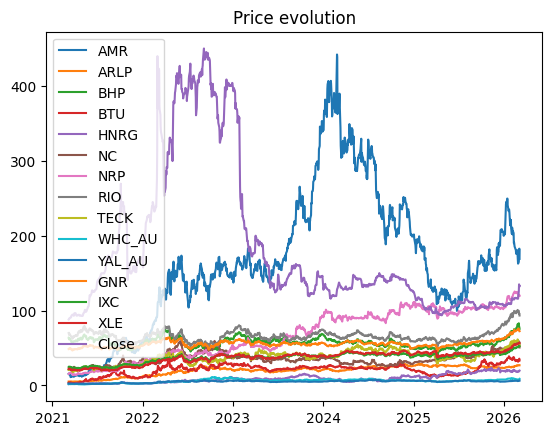

In [8]:
plt.figure()
for c in prices.columns:
    plt.plot(prices.index, prices[c],label=c)

plt.title("Price evolution")
plt.legend()
plt.show()

As we see, raw price series are not directly comparable due to differences in scale.
We have to normalize to focus on relative movements and co-movements between assets, rather than absolute price levels.

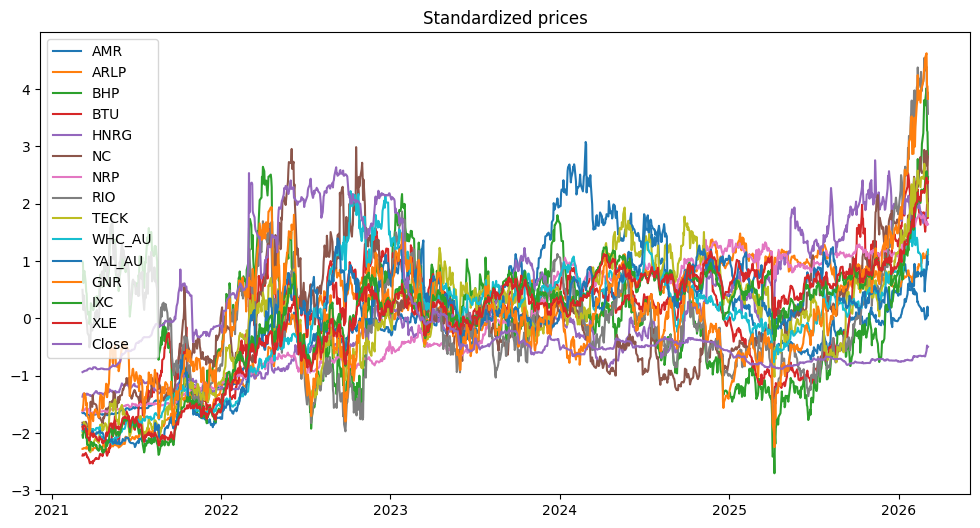

In [9]:
scaled_values = StandardScaler().fit_transform(prices)
scaled = pd.DataFrame(scaled_values, index=prices.index, columns=prices.columns)
plt.figure(figsize=(12,6))

for col in scaled.columns:
    plt.plot(scaled.index, scaled[col], label=col)

plt.title("Standardized prices")
plt.legend()
plt.show()

Despite the density of the plot, a clear common trend emerges across most assets.
The time series appear to move together, suggesting a strong underlying market factor driving their dynamics.
While some deviations exist, the overall co-movement is visually significant if we normalize the prices

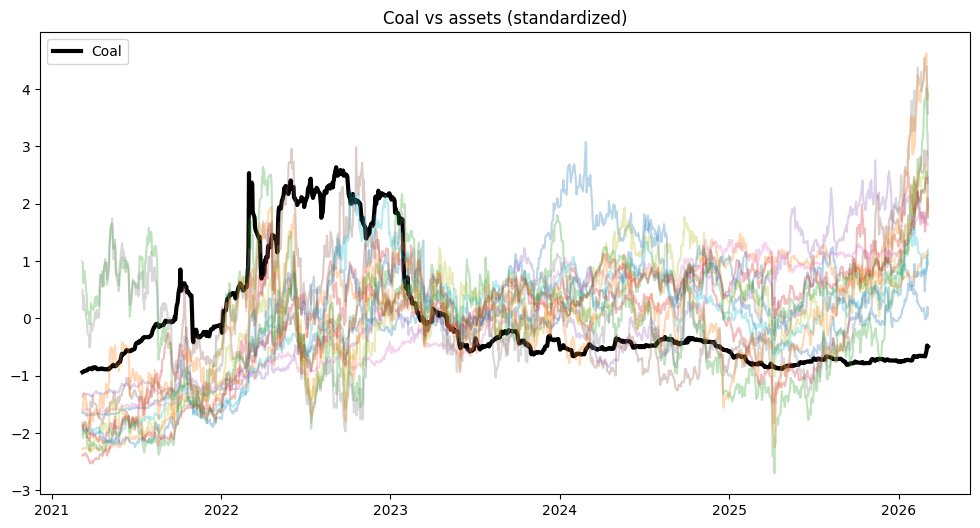

In [10]:
plt.figure(figsize=(12,6))

# charbon
plt.plot(scaled.index, scaled["Close"], color="black", linewidth=3, label="Coal")

# autres
for col in scaled.columns:
    if col != "Close":
        plt.plot(scaled.index, scaled[col], alpha=0.3)

plt.legend()
plt.title("Coal vs assets (standardized)")
plt.show()

Vérifions notre idée en testant la corrélation:

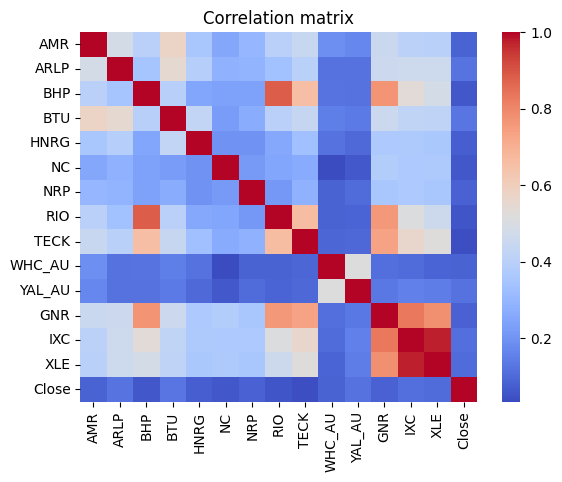

In [11]:
returns = prices.pct_change().dropna()
corr_matrix = returns.corr()
plt.figure()
sns.heatmap(corr_matrix, cmap="coolwarm")
plt.title("Correlation matrix")
plt.show()

The correlation levels with coal are relatively low across all assets, with values generally below 0.15.
This indicates that, while some relationship exists, it remains weak in terms of linear dependence. But weak correlation can still be usefull according to the Rafael Baptista Palazzi papper! We just have to hope that it's stable..

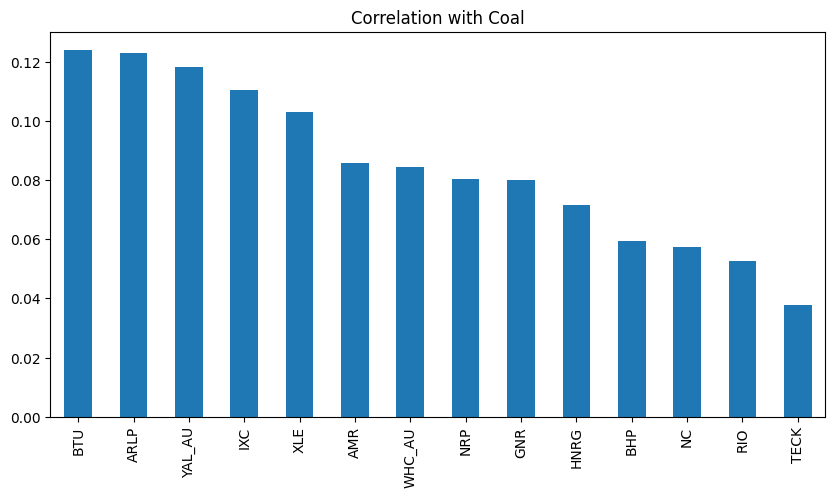

In [12]:
corr = returns.corr()["Close"].sort_values(ascending=False)
corr.drop("Close").plot(kind="bar", figsize=(10,5))
plt.title("Correlation with Coal")
plt.show()

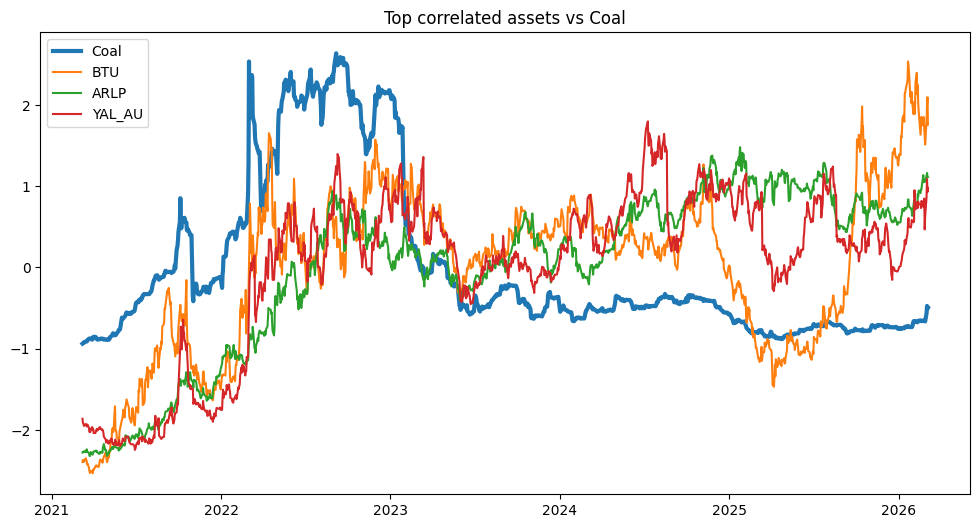

In [13]:
top_assets = corr.drop("Close").abs().sort_values(ascending=False).head(3).index

plt.figure(figsize=(12,6))

plt.plot(scaled.index, scaled["Close"], label="Coal", linewidth=3)

for col in top_assets:
    plt.plot(scaled.index, scaled[col], label=col)

plt.legend()
plt.title("Top correlated assets vs Coal")
plt.show()

The selected assets show a partial co-movement with coal, particularly during certain periods.
However, significant divergences are also visible, indicating that the relationship could be unstable over time.

Stationarity Test:

Before building the trading strategy, we first test whether the time series is stationary. This is important because the strategy relies on stable relationships between assets over time.

If the series is not stationary, the relationship may drift, making any trading signal unreliable.

This is why stationarity tests are performed: to ensure that the spread or the returns exhibit a stable behavior, which is necessary for a mean-reversion strategy like pairs trading.

In [14]:
print("ADF test on prices: \n")

for col in prices.columns:
    p = adfuller(prices[col])[1]
    if p < 0.05: #test at 95%
        print(col, ":",p, "->", "stationary")
    else:
        print(col,":",p,"->", "non-stationary")

ADF test on prices: 

AMR : 0.33829256097941457 -> non-stationary
ARLP : 0.290729737175192 -> non-stationary
BHP : 0.06484207438996678 -> non-stationary
BTU : 0.16018511623791704 -> non-stationary
HNRG : 0.8697126742812804 -> non-stationary
NC : 0.21762069019048053 -> non-stationary
NRP : 0.8453579463636157 -> non-stationary
RIO : 0.4126744085653658 -> non-stationary
TECK : 0.1964846793001681 -> non-stationary
WHC_AU : 0.3356486307224794 -> non-stationary
YAL_AU : 0.1769691590226088 -> non-stationary
GNR : 0.2830349827621885 -> non-stationary
IXC : 0.651883201477588 -> non-stationary
XLE : 0.7867740986673204 -> non-stationary
Close : 0.5416539025563478 -> non-stationary


In [15]:
print("ADF test on returns: \n")
for col in returns.columns:
    p = adfuller(returns[col])[1]
    if p < 0.05: 
        print(col, ":",p, "->", "stationary")
    else:
        print(col,":",p,"->", "non-stationary")

ADF test on returns: 

AMR : 0.0 -> stationary
ARLP : 0.0 -> stationary
BHP : 0.0 -> stationary
BTU : 0.0 -> stationary
HNRG : 0.0 -> stationary
NC : 0.0 -> stationary
NRP : 0.0 -> stationary
RIO : 0.0 -> stationary
TECK : 3.108160204358892e-29 -> stationary
WHC_AU : 0.0 -> stationary
YAL_AU : 3.269169594375899e-25 -> stationary
GNR : 0.0 -> stationary
IXC : 0.0 -> stationary
XLE : 0.0 -> stationary
Close : 0.0 -> stationary


Prices are non-stationary, which is consistent with a random walk behavior but returns are stationary (or almost), confirming they fluctuate around a stable mean. This validates the use of returns for modeling and motivates testing stationarity on spreads for pairs trading.

Outlayer test:

In [16]:
z = (returns - returns.mean()) / returns.std()
outliers = (abs(z) > 3)# For a gaussian distribution, observations beyond 3 standard deviations are considered rare.

print(outliers.sum())

AMR       18
ARLP      14
BHP        9
BTU       17
HNRG      17
NC        18
NRP       20
RIO        7
TECK      15
WHC_AU    12
YAL_AU    21
GNR       12
IXC       14
XLE       13
Close     22
dtype: int64


That's quite a few number, which means the data quality is good globally. Now let's see if they are errors or just extreme events

In [17]:
threshold = 0.25  # a movement of 25%: is theorically possible but way too much rare. These kind of outlayer require our full attention.

suspect_dict = {} # We keep suspicious events

for col in returns.columns:
    outlier_dates = z[z[col].abs() > 3].index
    
    suspect = 0
    total = len(outlier_dates)
    
    suspect_dates = []  
    
    for date in outlier_dates:
        
        r_t = returns.loc[date, col]
        r_prev = returns.shift(1).loc[date, col]
        r_next = returns.shift(-1).loc[date, col]
    
        if abs(r_t - r_prev) > threshold and abs(r_t - r_next) > threshold:
            suspect += 1
            suspect_dates.append(date)

    
    if suspect_dates:
        suspect_dict[col] = suspect_dates
    
    print(f"{col}: {suspect}/{total} suspect")


AMR: 0/18 suspect
ARLP: 0/14 suspect
BHP: 0/9 suspect
BTU: 3/17 suspect
HNRG: 1/17 suspect
NC: 0/18 suspect
NRP: 0/20 suspect
RIO: 0/7 suspect
TECK: 0/15 suspect
WHC_AU: 0/12 suspect
YAL_AU: 0/21 suspect
GNR: 0/12 suspect
IXC: 0/14 suspect
XLE: 0/13 suspect
Close: 3/22 suspect


In [18]:
for col, dates in suspect_dict.items():
    print(f"\n{col}:")
    for d in dates:
        print(d.date())


BTU:
2021-05-17
2021-07-07
2022-02-24

HNRG:
2025-01-27

Close:
2021-11-01
2022-03-02
2022-03-03


The analysis of detected outliers shows that most extreme movements are consistent with known market events. For BTU, the 2021 outliers align with the post-COVID commodity supercycle, while the 2022-02-24 spike corresponds to the Russia–Ukraine war beginning and the resulting energy shock.

For Newcastle coal futures, the 2021-11-01 movement reflects the global energy crisis, and the 2022-03-02/03 spikes are directly linked to the escalation of the war and commodity price surges.

The only unexplained case is HNRG on 2025-01-27, which does not match any macro event we found, possibly due to firm-specific factors or low liquidity. Overall, the outliers are economically justified and do not indicate data errors.